# Linear Analysis

Parse `perf_metrics.txt`, build the wide dataframes used by the plots, and visualize DRAM utilization vs normalized performance.

### need to rerun A100 VGG16, resnet101

In [2]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path('/home/ac.zzheng/power/GPGPU/coSched/data')
FIG_DIR = Path('/home/ac.zzheng/power/GPGPU/coSched/fig')
SYSTEMS = ['H100', 'A100', 'V100']
SECTION_RE = re.compile(r'^===== .*?/([^/ ]+) =====$')


def parse_edp_metrics(metrics_path: Path) -> pd.DataFrame:
    rows = []
    current_benchmark = None

    for raw_line in metrics_path.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue

        match = SECTION_RE.match(line)
        if match:
            current_benchmark = match.group(1)
            continue

        if current_benchmark is None or line.startswith('cap=') or line.startswith('gpu_count'):
            continue

        parts = line.split()
        if len(parts) < 6:
            continue

        rows.append({
            'benchmark': current_benchmark,
            'gpu_count': int(parts[0]),
            'performance': float(parts[1]),
            'avg_power': float(parts[2]),
            'dram_sum': float(parts[3]),
            'sm_sum': float(parts[4]),
            'fp_sum': float(parts[5]),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f'No rows parsed from {metrics_path}')

    df['gpu_label'] = df['gpu_count'].astype(str) + ' GPU'
    return df


# Parse all systems
all_edp = {}
all_perf = {}
all_dram = {}

for sys_name in SYSTEMS:
    edp_df = parse_edp_metrics(DATA_ROOT / sys_name / 'perf_metrics.txt')
    col_names = [f'{g} GPU' for g in sorted(edp_df['gpu_count'].unique())]

    perf_df = (
        edp_df.pivot(index='benchmark', columns='gpu_label', values='performance')
        .reindex(columns=col_names).sort_index()
    )
    dram_df = (
        edp_df.pivot(index='benchmark', columns='gpu_label', values='dram_sum')
        .reindex(columns=col_names).sort_index()
    )

    all_edp[sys_name] = edp_df
    all_perf[sys_name] = perf_df
    all_dram[sys_name] = dram_df

# Show H100 perf table
# all_perf['H100']

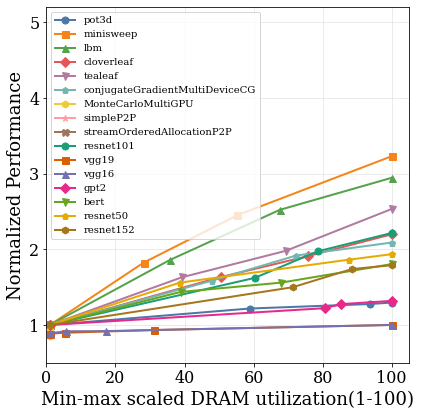

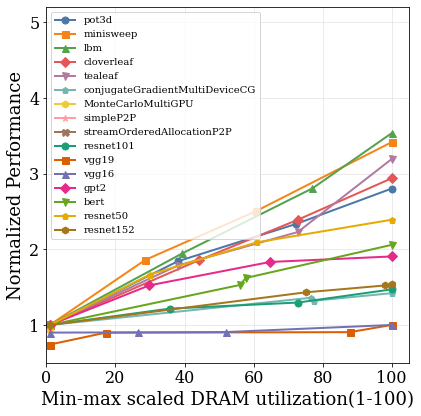

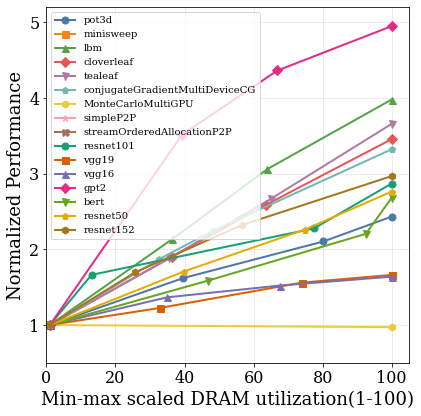

In [3]:
def minmax_scale_rows(df, out_min=1, out_max=100):
    row_min = df.min(axis=1)
    row_max = df.max(axis=1)
    row_range = row_max - row_min
    scaled = df.sub(row_min, axis=0).div(row_range.replace(0, np.nan), axis=0)
    scaled = scaled * (out_max - out_min) + out_min
    scaled = scaled.where(row_range.ne(0), out_min)
    return scaled.round(3)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
})

colors_pool = [
    '#4C78A8', '#F58518', '#54A24B', '#E45756', '#B07AA1',
    '#72B7B2', '#EECA3B', '#FF9DA6', '#9D755D', '#1B9E77',
    '#D95F02', '#7570B3', '#E7298A', '#66A61E', '#E6AB02',
    '#A6761D', '#666666',
]

markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X']

target_benchmarks = [
    'pot3d', 'minisweep', 'lbm', 'cloverleaf', 'tealeaf',
    'conjugateGradientMultiDeviceCG','MonteCarloMultiGPU','simpleP2P',
    'streamOrderedAllocationP2P',"resnet101", "vgg19","vgg16","gpt2",
    'bert', 'resnet50', 'resnet152'
]
# target_benchmarks = [
#     'miniweather'
# ]

FIG_DIR.mkdir(parents=True, exist_ok=True)

for sys_name in SYSTEMS:
    perf_df = all_perf[sys_name]
    dram_df = all_dram[sys_name]

    # Normalized perf = runtime_1GPU / runtime_NGPU
    norm_perf = perf_df.rdiv(perf_df['1 GPU'], axis=0).round(3)
    norm_dram = minmax_scale_rows(dram_df, 1, 100)

    # Filter to target benchmarks available in this system
    avail = [b for b in target_benchmarks if b in norm_perf.index]
    norm_perf = norm_perf.reindex(avail)
    norm_dram = norm_dram.reindex(avail)

    if norm_perf.empty:
        print(f'{sys_name}: no target benchmarks found, skipping')
        continue

    fig, ax = plt.subplots(figsize=(6, 6))

    for i, app in enumerate(norm_perf.index):
        x_vals = norm_dram.loc[app].values
        y_vals = norm_perf.loc[app].values
        # Sort by x (DRAM) so line doesn't backtrack
        order = np.argsort(x_vals)
        ax.plot(x_vals[order], y_vals[order], marker=markers[i % len(markers)],
                color=colors_pool[i % len(colors_pool)],
                label=app, linewidth=2, markersize=7)


    ax.set_xlabel('Min-max scaled DRAM utilization(1-100)', fontsize=18)
    ax.set_ylabel('Normalized Performance', fontsize=18)
    # ax.set_title(sys_name, fontsize=18, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 105)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_ylim(0.5, 5.2)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / f'dram_utilization_vs_performance_{sys_name}.png', dpi=300)
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './fig/gpu_count_vs_dram_utilization.png'

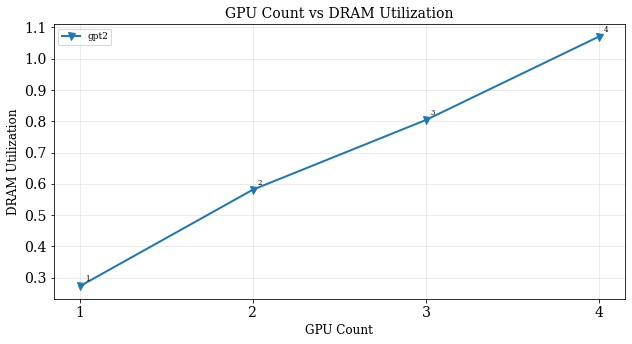

In [27]:
col_names = [f'{gpu_count} GPU' for gpu_count in sorted(edp_df['gpu_count'].unique())]
gpu_cols_int = [int(col.split()[0]) for col in col_names]

# Plot: GPU count vs DRAM utilization for each app
fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X']

gpu_vals = gpu_cols_int

for i, app in enumerate(dram_df.index):
    if app not in target_benchmarks:
        continue

    y_vals = dram_df.loc[app, col_names].values
    ax.plot(gpu_vals, y_vals, marker=markers[i % len(markers)], label=app,
            linewidth=2, markersize=7)

    for j, gpu_n in enumerate(gpu_vals):
        ax.annotate(f'{gpu_n}', (gpu_vals[j], y_vals[j]),
                    textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlabel('GPU Count', fontsize=12)
ax.set_ylabel('DRAM Utilization', fontsize=12)
ax.set_title('GPU Count vs DRAM Utilization', fontsize=14)
ax.set_xticks(gpu_vals)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./fig/gpu_count_vs_dram_utilization.png', dpi=300)
plt.show()